In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, plot_bloch_vector

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np

### 1) Crie um circuito quântico e faça a codificação para cada uma das strings a seguir. Em seguida, realize as medições necessárias. Mostre o diagrama de circuito e o histograma do resultado de simulação utilizando um simulador.

a) A = 10011101 (realize a medição de todos os qubits)

b) B = 10101010 (realize a medição apenas dos qubits inicializados em |1〉)

In [2]:
def codifica_mede(bitstring, measure_only_ones=False):
    n = len(bitstring)

    # inicializa com |1>
    ones = [i for i, bit in enumerate(reversed(bitstring)) if bit == "1"]

    n_classical = len(ones) if measure_only_ones else n
    qc = QuantumCircuit(n, n_classical)

    # encoding
    for q in ones:
        qc.x(q)

    qc.barrier()

    # medir
    if measure_only_ones:
        for c, q in enumerate(ones):
            qc.measure(q, c)
    else:
        qc.measure(range(n), range(n))

    print(qc.draw())

    simulator = AerSimulator()
    result = simulator.run(qc, shots=1024).result()
    counts = result.get_counts()

    print("Resultado:", counts)

    plot_histogram(counts)
    plt.show()

    return qc, counts

In [3]:
# a)
print("a)")
qc_A, counts_A = codifica_mede("10011101")

print("\n\n")

# b)
print("b)")
qc_B, counts_B = codifica_mede(
    "10101010",
    measure_only_ones=True
)

a)
     ┌───┐ ░ ┌─┐                     
q_0: ┤ X ├─░─┤M├─────────────────────
     └───┘ ░ └╥┘┌─┐                  
q_1: ──────░──╫─┤M├──────────────────
     ┌───┐ ░  ║ └╥┘┌─┐               
q_2: ┤ X ├─░──╫──╫─┤M├───────────────
     ├───┤ ░  ║  ║ └╥┘┌─┐            
q_3: ┤ X ├─░──╫──╫──╫─┤M├────────────
     ├───┤ ░  ║  ║  ║ └╥┘┌─┐         
q_4: ┤ X ├─░──╫──╫──╫──╫─┤M├─────────
     └───┘ ░  ║  ║  ║  ║ └╥┘┌─┐      
q_5: ──────░──╫──╫──╫──╫──╫─┤M├──────
           ░  ║  ║  ║  ║  ║ └╥┘┌─┐   
q_6: ──────░──╫──╫──╫──╫──╫──╫─┤M├───
     ┌───┐ ░  ║  ║  ║  ║  ║  ║ └╥┘┌─┐
q_7: ┤ X ├─░──╫──╫──╫──╫──╫──╫──╫─┤M├
     └───┘ ░  ║  ║  ║  ║  ║  ║  ║ └╥┘
c: 8/═════════╩══╩══╩══╩══╩══╩══╩══╩═
              0  1  2  3  4  5  6  7 
Resultado: {'10011101': 1024}



b)
           ░             
q_0: ──────░─────────────
     ┌───┐ ░ ┌─┐         
q_1: ┤ X ├─░─┤M├─────────
     └───┘ ░ └╥┘         
q_2: ──────░──╫──────────
     ┌───┐ ░  ║ ┌─┐      
q_3: ┤ X ├─░──╫─┤M├──────
     └───┘ ░  ║ └╥┘      
q_4: 

### 2) Utilizando a instrução plot_bloch_vector com coordenadas esféricas do Qiskit, plote na esfera de Bloch os estados a seguir: |0〉, |1〉, |+〉, |−〉, |+i〉,|−i〉. 

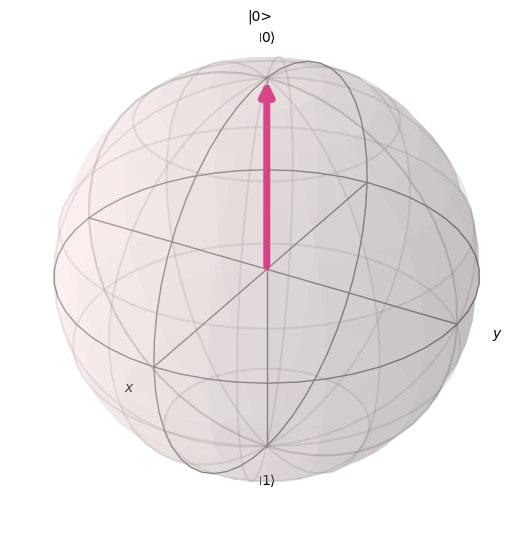

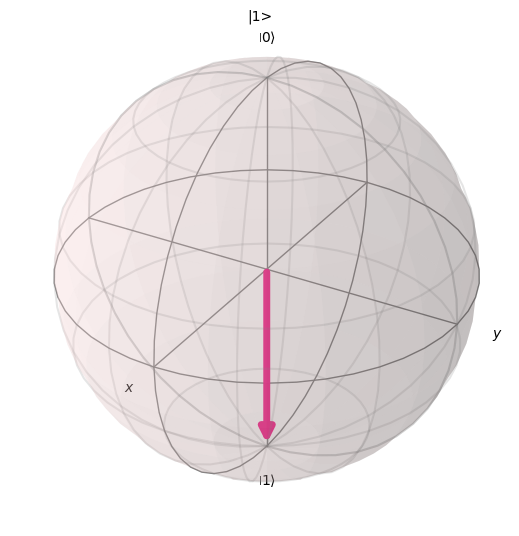

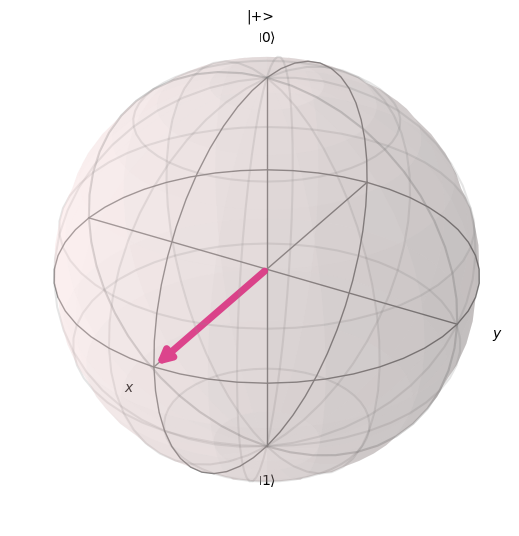

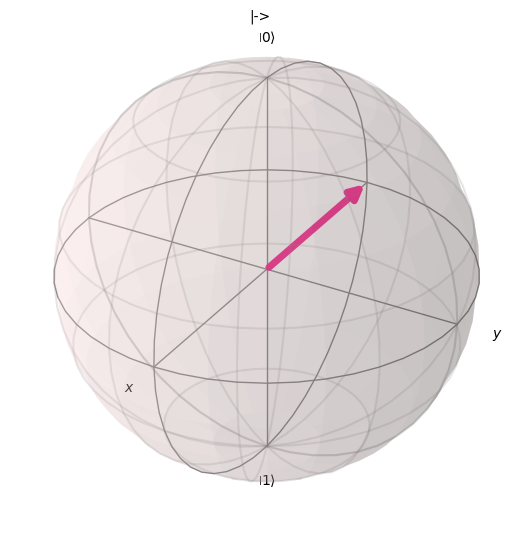

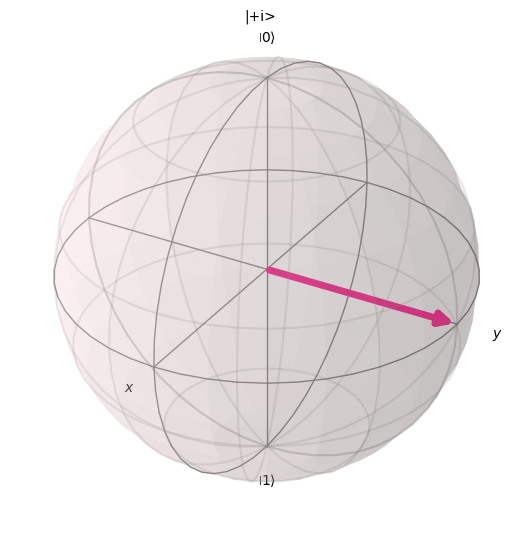

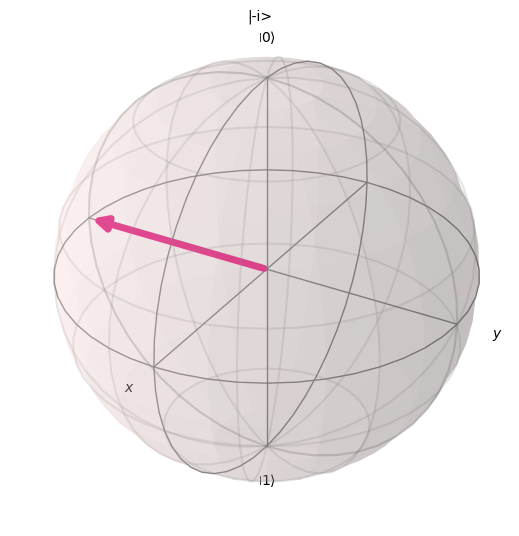

In [4]:
states = {
    "|0>":  [1, 0, 0],
    "|1>":  [1, np.pi, 0],
    "|+>":  [1, np.pi/2, 0],
    "|->":  [1, np.pi/2, np.pi],
    "|+i>": [1, np.pi/2, np.pi/2],
    "|-i>": [1, np.pi/2, -np.pi/2]
}

for name, coords in states.items():
    fig = plot_bloch_vector(
        coords,
        coord_type="spherical",
        title=name
    )
    display(fig)

### 3) Construa um circuito de 1 qubit formado apenas pelas portas H, Z, Y aplicadas nessa ordem. Qual o estado final que obteremos? Mostre o diagrama de circuito e a plotagem do estado inicial e final na esfera de Bloch (utilize a instrução plot_bloch_vector com coordenadas esféricas do Qiskit).

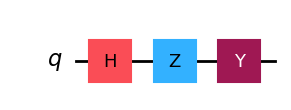

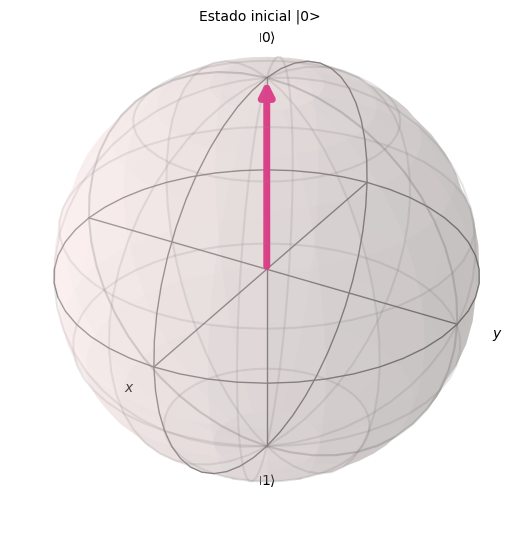

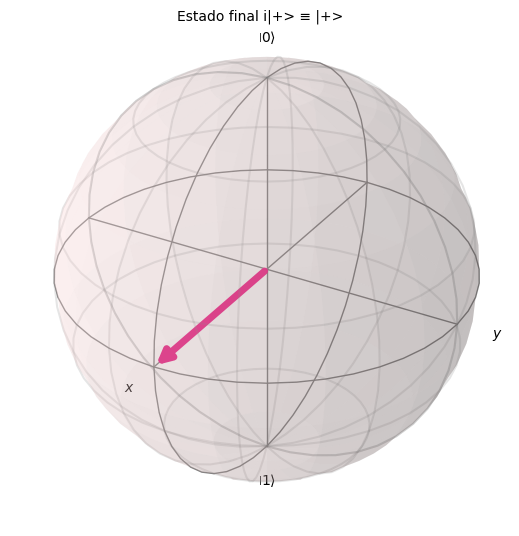

In [5]:
qc = QuantumCircuit(1)

qc.h(0)
qc.z(0)
qc.y(0)

# Diagrama
display(qc.draw("mpl"))

# Estado inicial |0> = +Z
display(
    plot_bloch_vector(
        [1, 0, 0],
        coord_type="spherical",
        title="Estado inicial |0>"
    )
)

# Estado final |+> = +X
display(
    plot_bloch_vector(
        [1, np.pi/2, 0],
        coord_type="spherical",
        title="Estado final i|+> ≡ |+>"
    )
)

#### Estado final |+> = +X

### 4) Utilizando portas Hadamard, construa um circuito para gerar números aleatórios de 2 bits. Execute no simulador e mostre os histogramas após a medição. 

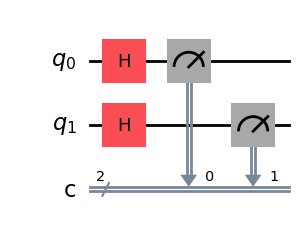

Resultados: {'01': 269, '11': 283, '00': 247, '10': 225}


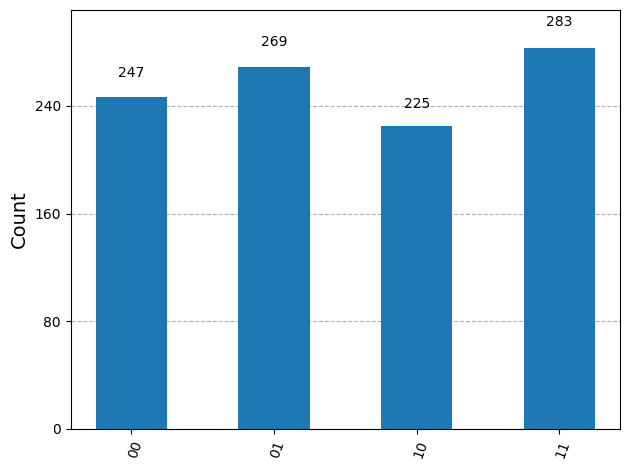

In [6]:
qc = QuantumCircuit(2, 2)

qc.h(0)
qc.h(1)

qc.measure([0, 1], [0, 1])

display(qc.draw("mpl"))

sim = AerSimulator()
result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

print("Resultados:", counts)

display(plot_histogram(counts))

### 5) Construa um circuito de 1 qubit e, utilizando apenas portas H e P, o coloque no estado 1√2(1−(√2+i√2)/2) expresso na base computacional e com amplitudes de probabilidades reais. Mostre o diagrama de circuito e a plotagem do estado final na esfera de Bloch.



$$
|\psi\rangle=\frac{1}{\sqrt2}
\left(
|0\rangle-\frac{\sqrt2+i\sqrt2}{2}|1\rangle
\right)

temos

-\frac{\sqrt2+i\sqrt2}{2}
=-\frac{1+i}{\sqrt2}
=e^{i5\pi/4}.
$$

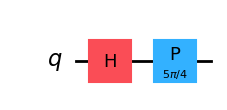

Estado final: [ 0.70710678+0.j  -0.5       -0.5j]
Probabilidades: [0.5 0.5]


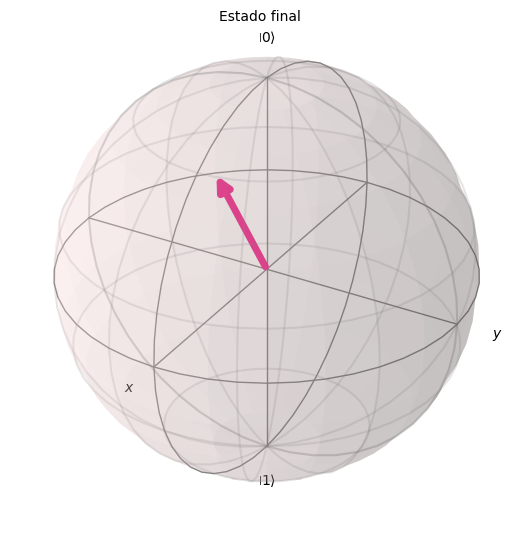

In [7]:
qc = QuantumCircuit(1)

qc.h(0)
qc.p(5*np.pi/4, 0)

# Diagrama
display(qc.draw("mpl"))

# Estado final
state = Statevector.from_instruction(qc)
print("Estado final:", state.data)
print("Probabilidades:", state.probabilities())

# Esfera de Bloch
display(
    plot_bloch_vector(
        [1, np.pi/2, 5*np.pi/4],
        coord_type="spherical",
        title="Estado final"
    )
)

### 6) Construa um circuito de 2 qubits e os coloque no estado (|q1q0〉=|10〉). Coloque os dois qubits em superposição. Leve o qubit q0 ao estado |-i〉 utilizando apenas portas Z e T, e o qubit q1 ao estado |+i〉 utilizando apenas a porta S. Mostre o diagrama de circuito e a plotagem na esfera de Bloch dos estados finais.

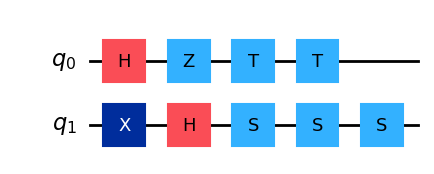

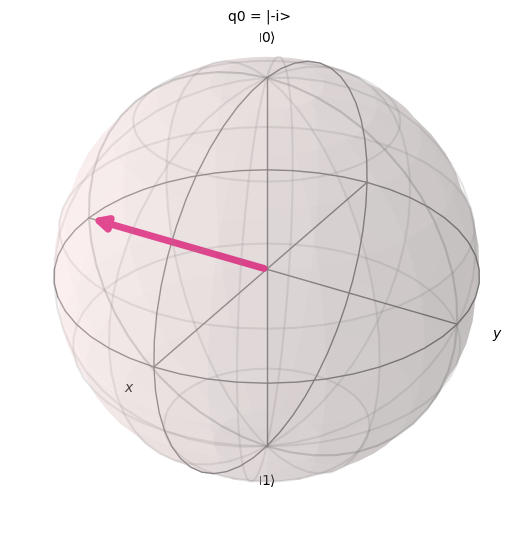

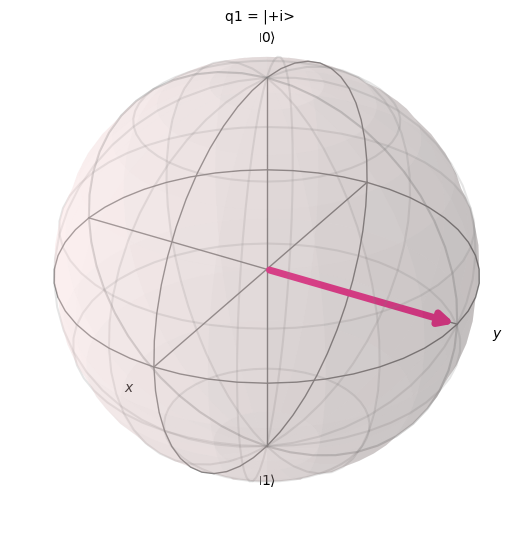

In [8]:
qc = QuantumCircuit(2)

# Estado inicial |q1 q0> = |10>
qc.x(1)

# Superposição
qc.h(0)
qc.h(1)

# q0 -> |-i>
qc.z(0)
qc.t(0)
qc.t(0)

# q1 -> |+i>
qc.s(1)
qc.s(1)
qc.s(1)

# Diagrama
display(qc.draw("mpl"))

# q0 = |-i> -> -Y
display(plot_bloch_vector(
    [1, np.pi/2, -np.pi/2],
    coord_type="spherical",
    title="q0 = |-i>"
))

# q1 = |+i> -> +Y
display(plot_bloch_vector(
    [1, np.pi/2, np.pi/2],
    coord_type="spherical",
    title="q1 = |+i>"
))

### 7) Vimos que o uso em conjunto de uma porta de Hadamard e uma porta CNOT permite construir um estado emaranhado chamado de estado de Bell. Entretanto, temos outros estados emaranhados que também recebem esse nome. Construa um circuito quântico que implemente o estado de bell: (1√2)∗(|01〉+|10〉). Execute em um simulador e mostre o diagrama de circuito e o histograma do resultado da simulação.

Para gerar

$$
|\Psi^+\rangle=\frac{1}{\sqrt2}(|01\rangle+|10\rangle)
$$ 

podemos gerar primeiro 

$$ (|00\rangle+|11\rangle)/\sqrt2 $$

 com H + CNOT e depois aplicar X em um dos qubits:

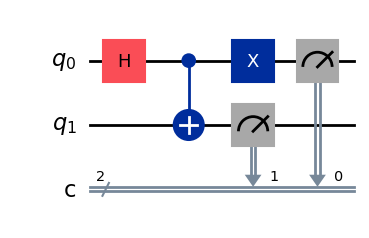

Resultados: {'10': 503, '01': 521}


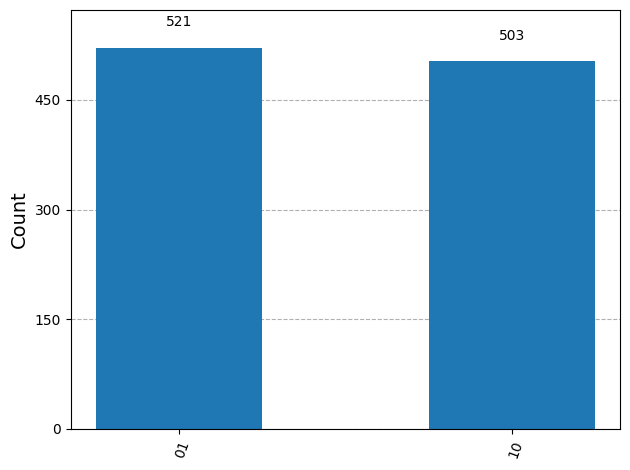

In [9]:
qc = QuantumCircuit(2, 2)

# Estado de Bell: (|01> + |10>)/sqrt(2)
qc.h(0)
qc.cx(0, 1)
qc.x(0)

# Medição
qc.measure([0, 1], [0, 1])

# Circuito
display(qc.draw("mpl"))

# Simulação
sim = AerSimulator()
result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

print("Resultados:", counts)

display(plot_histogram(counts))

### 8) Construa um circuito com 4 qubits (q0, q1, q2, q3) e 3 bits clássicos (c0, c1, c2) e prepare os qubits q0 e q2 no estado |1〉. Aplique ao estado q3 um bit-flip controlado pelos estados q0 e q2. Em seguida, use o estado q3 para controlar a troca de estados entre q1 e q2. Realize a medição dos estados q1, q2 e q3 nos bits c0, c1 e c2, respectivamente. Mostre o diagrama de circuito, execute em um simulador e mostre o histograma dos resultados.

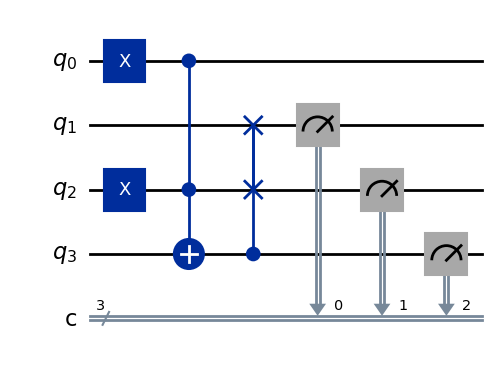

Resultados: {'101': 1024}


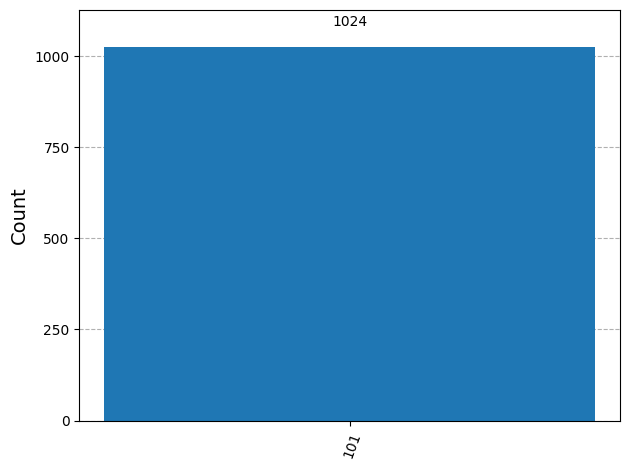

In [10]:
qc = QuantumCircuit(4, 3)

# q0 e q2 em |1>
qc.x(0)
qc.x(2)

# Bit-flip em q3 controlado por q0 e q2
qc.ccx(0, 2, 3)

# q3 controla a troca entre q1 e q2
qc.cswap(3, 1, 2)

# q1 -> c0, q2 -> c1, q3 -> c2
qc.measure(1, 0)
qc.measure(2, 1)
qc.measure(3, 2)

display(qc.draw("mpl"))

sim = AerSimulator()
result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

print("Resultados:", counts)

display(plot_histogram(counts))